In [3]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ------- -------------------------------- 7.9/40.2 MB 34.5 MB/s eta 0:00:01
   ---------------- ----------------------- 16.8/40.2 MB 39.3 MB/s eta 0:00:01
   -------------------------- ------------- 26.2/40.2 MB 40.0 MB/s eta 0:00:01
   ------------------------------------ --- 37.0/40.2 MB 42.5 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 42.3 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 32.7 MB/s  0:00:01


In [9]:
import pandas as pd
import numpy as np

from glob import glob

import cv2
import matplotlib.pylab as plt

plt.style.use('ggplot')

## Reading in Images

In [10]:
doreamon = glob("./images/doreamon/*.png")
sinchan = glob("./images/sinchan/*.jpg")

In [11]:
sinchan

['./images/sinchan\\img4.jpg',
 './images/sinchan\\img5.jpg',
 './images/sinchan\\img6.jpg']

((201, 251, 3), (201, 251, 3))

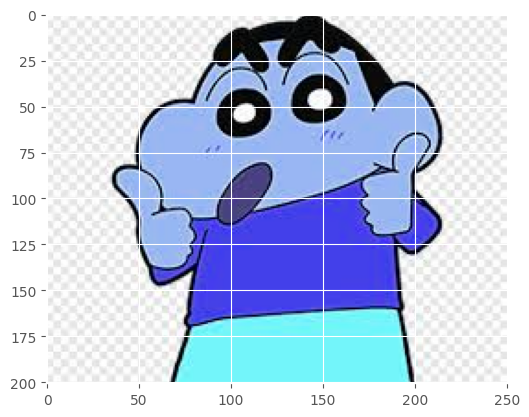

In [25]:
img_mpl = plt.imread(sinchan[2])
img_cv2 = cv2.imread(sinchan[2])
plt.imshow(img_cv2)
img_mpl.shape, img_cv2.shape

### Image Array¶
(Height, Width, Channels)
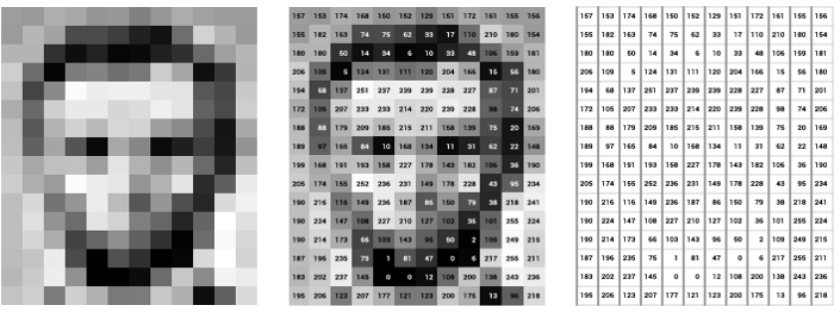

In [5]:
img_mpl.flatten()

array([255, 255, 255, ..., 245, 245, 245], shape=(151353,), dtype=uint8)

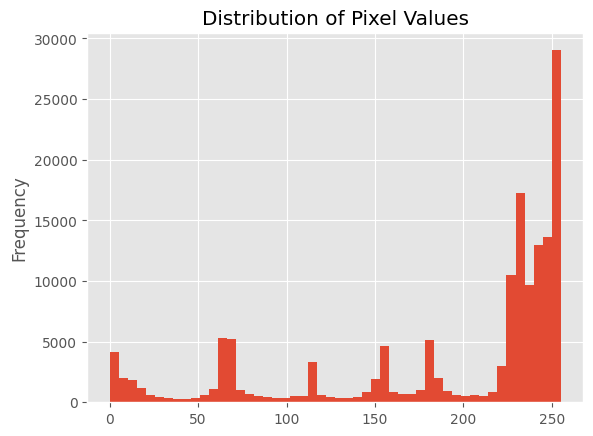

In [6]:
pd.Series(img_mpl.flatten()).plot(kind='hist',
                                  bins=50,
                                  title='Distribution of Pixel Values')
plt.show()

## Display Images

In [13]:
img = plt.imread("parrot.jpg")

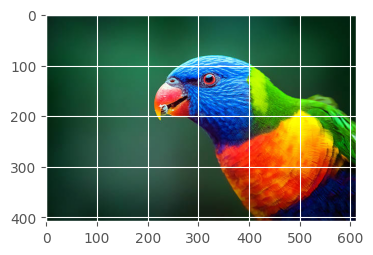

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img)
#ax.axis('off')
plt.show()

## RGB Channels¶
An RGB image has three channels: red, green, and blue. RGB channels roughly follow the color receptors in the human eye, and are used in computer displays and image scanners.
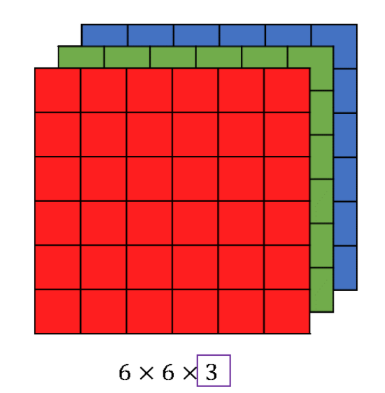

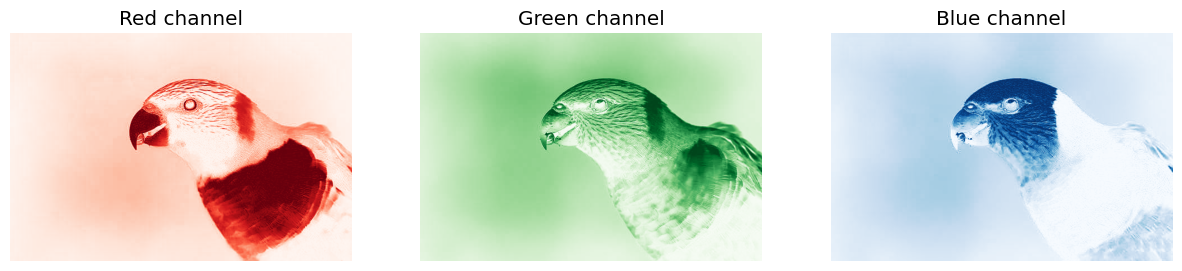

In [20]:
# Display RGB Channels of our image
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img[:,:,0], cmap='Reds')
axs[1].imshow(img[:,:,1], cmap='Greens')
axs[2].imshow(img[:,:,2], cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
plt.show()

## Matplotlib vs cv2 Numpy Arrays¶
- cv2 reads in channels as BGR
- matplotlib reads in channels as RGB

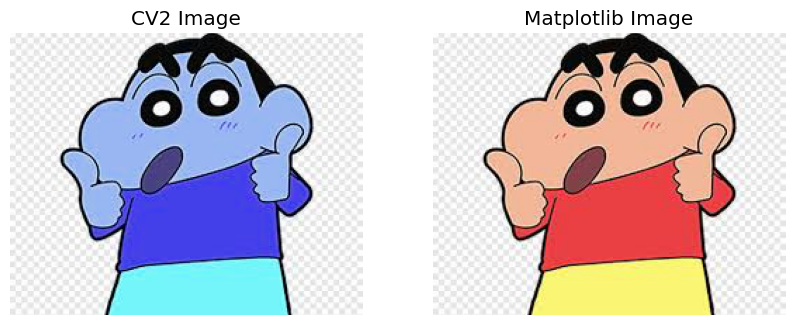

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_cv2)
axs[1].imshow(img_mpl)
axs[0].axis('off')
axs[1].axis('off')
axs[0].set_title('CV2 Image')
axs[1].set_title('Matplotlib Image')
plt.show()

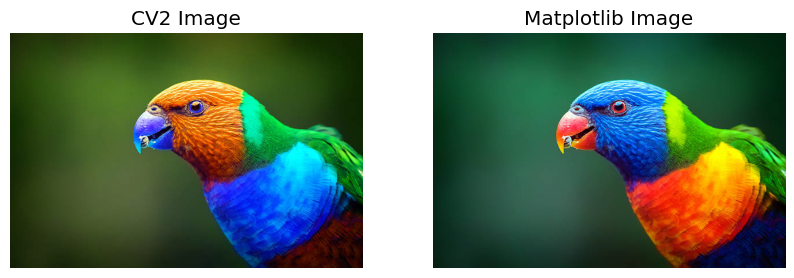

In [16]:
img_cv = cv2.imread("parrot.jpg")
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_cv)
axs[1].imshow(img)
axs[0].axis('off')
axs[1].axis('off')
axs[0].set_title('CV2 Image')
axs[1].set_title('Matplotlib Image')
plt.show()

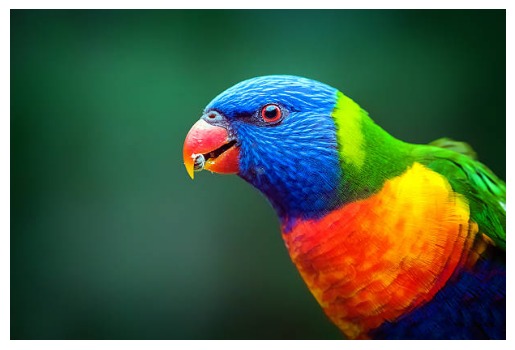

In [17]:
# Converting from BGR to RGB
img_cv2_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots()
ax.imshow(img_cv2_rgb)
ax.axis('off')
plt.show()

## Image Manipulation

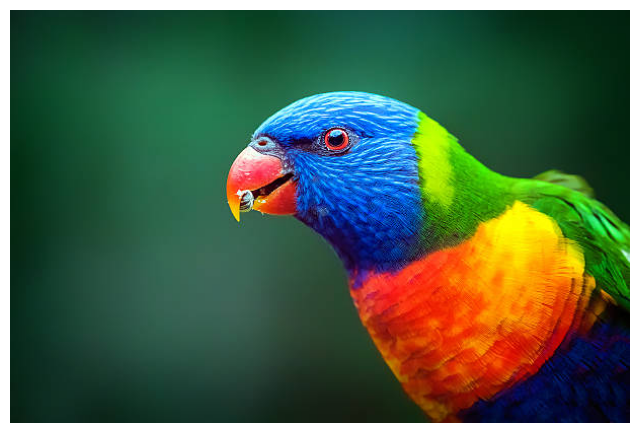

In [18]:
img = plt.imread("parrot.jpg")
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.axis('off')
plt.show()

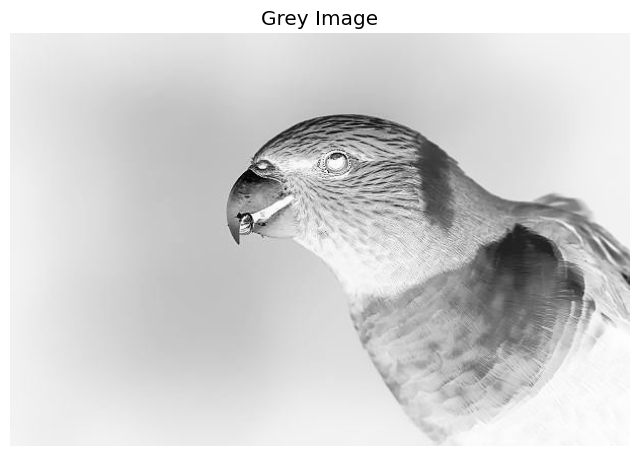

In [19]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_gray, cmap='Greys')
ax.axis('off')
ax.set_title('Grey Image')
plt.show()

## Resizing and Scaling

- **Interpolation** means estimating new pixel values from surrounding pixels.

In [20]:
img.shape

(408, 612, 3)

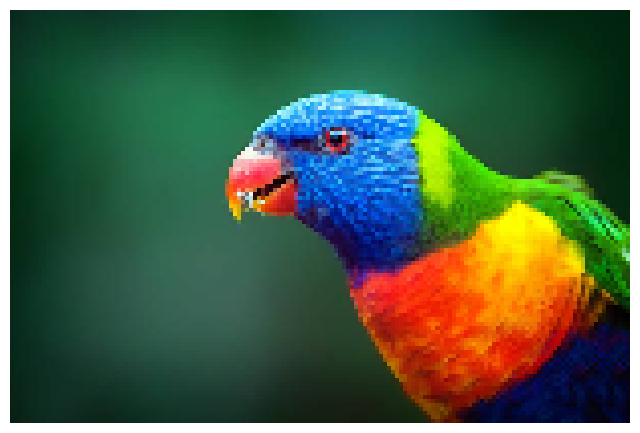

(102, 153, 3)

In [22]:
img_resized = cv2.resize(img, None, fx=0.25, fy=0.25)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_resized)
ax.axis('off')
plt.show()
img_resized.shape

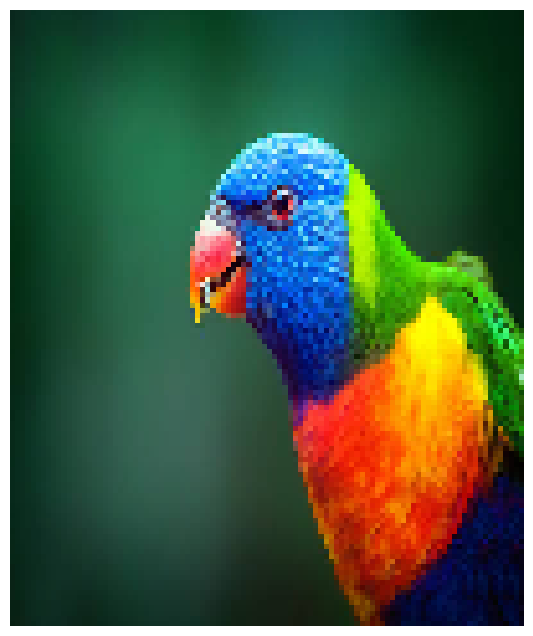

In [23]:
# Different Size
img_resize = cv2.resize(img, (100, 120))
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_resize)
ax.axis('off')
plt.show()

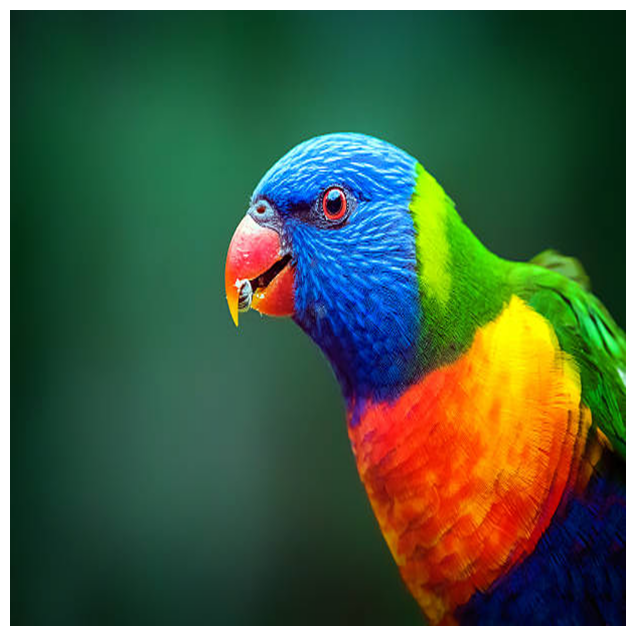

In [24]:
img_resize = cv2.resize(img, (5000, 5000), interpolation = cv2.INTER_CUBIC)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_resize)
ax.axis('off')
plt.show()

## CV2 Kernels
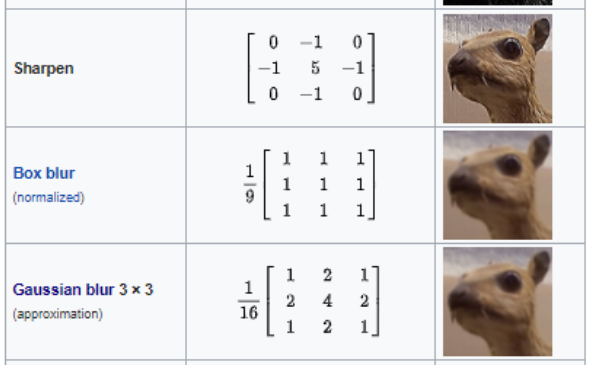

## filter
- `cv2.filter2D()` applies a kernel matrix to every pixel of an image to produce effects like **blur, sharpen, or edge detection**

- Syntax

      - `cv2.filter2D(src, ddepth, kernel)`

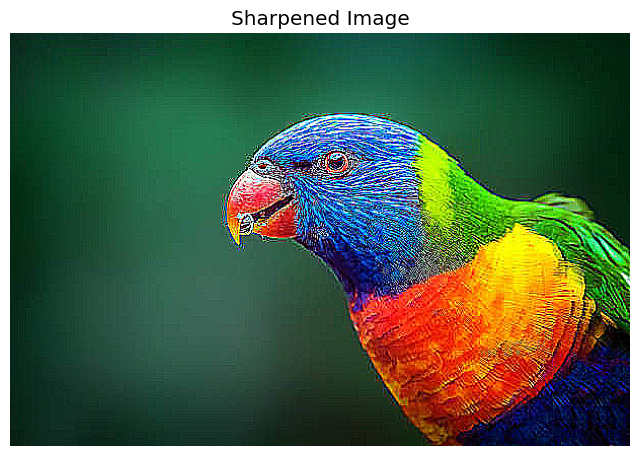

In [25]:
# Sharpen Image
kernel_sharpening = np.array([[-1,-1,-1], 
                              [-1,9,-1], 
                              [-1,-1,-1]])

sharpened = cv2.filter2D(img, -1, kernel_sharpening)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(sharpened)
ax.axis('off')
ax.set_title('Sharpened Image')
plt.show()

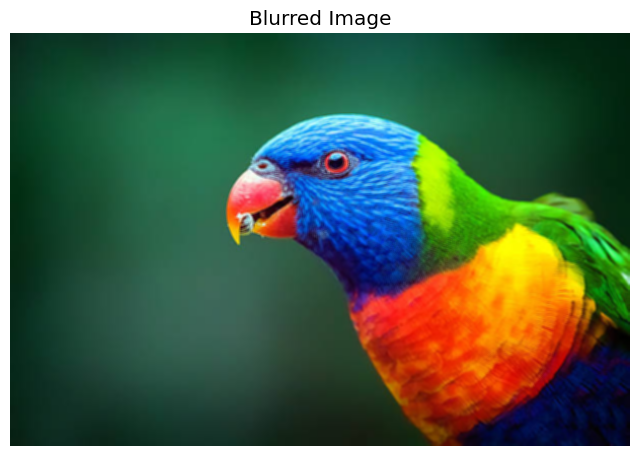

In [26]:
# Blurring the image
kernel_3x3 = np.ones((3, 3), np.float32) / 9
blurred = cv2.filter2D(img, -1, kernel_3x3)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(blurred)
ax.axis('off')
ax.set_title('Blurred Image')
plt.show()

## Save image

In [34]:
plt.imsave('sample1.png', blurred)
cv2.imwrite('sample2.png', blurred)

True

In [1]:
import numpy as np
from PIL import Image

In [2]:
img = Image.open("./parrot.jpg")

In [5]:
np.array(img).shape

(408, 612, 3)

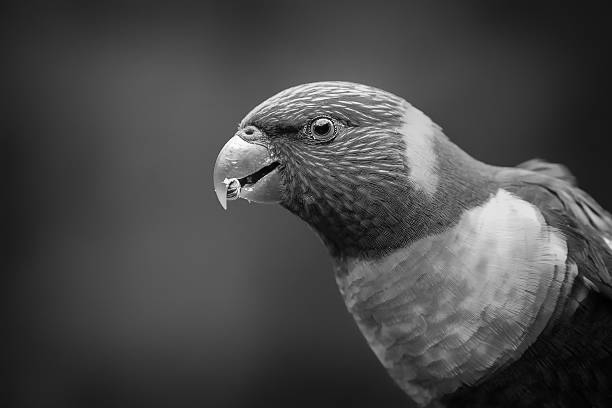

In [8]:
img.convert(mode="L")